<a href="https://colab.research.google.com/github/firmanadikk/frmnadk/blob/main/Proyek_Analisis_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyek Analisis Data: Firman Adi Kurniawan
- **Nama:** Firman Adi Kurniawan
- **Email:** firmanadik09@gmail.com
- **ID Dicoding:** CDCC006D6Y2351


## Menentukan Pertanyaan Bisnis

- Pada periode 2016–2018, bagaimana tren jumlah order per bulan dan pada hari apa pelanggan paling banyak melakukan pembelian, sehingga dapat digunakan sebagai dasar penentuan waktu optimal untuk kampanye promosi?
- Pada periode 2016–2018, kategori produk apa yang menghasilkan revenue dan volume penjualan tertinggi, sehingga dapat menjadi prioritas pengembangan inventaris dan strategi pemasaran?

## Import Semua Packages/Library yang Digunakan

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns


## Data Wrangling

### Gathering Data

In [3]:
from google.colab import drive
drive.mount('/content/drive')
orders = pd.read_csv('/content/drive/MyDrive/E-CommercePublicDataset/orders_dataset.csv')
items = pd.read_csv('/content/drive/MyDrive/E-CommercePublicDataset/order_items_dataset.csv')
payments = pd.read_csv('/content/drive/MyDrive/E-CommercePublicDataset/order_payments_dataset.csv')
reviews = pd.read_csv('/content/drive/MyDrive/E-CommercePublicDataset/order_reviews_dataset.csv')
products = pd.read_csv('/content/drive/MyDrive/E-CommercePublicDataset/products_dataset.csv')
cat_trans = pd.read_csv('/content/drive/MyDrive/E-CommercePublicDataset/product_category_name_translation.csv')

Mounted at /content/drive


In [4]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [5]:
items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [6]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [7]:
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [8]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [9]:
cat_trans.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


**Insight:**
### Gathering Data

Pada tahap ini, dilakukan pengumpulan data dari 6 file CSV yang merupakan bagian dari
Brazilian E-Commerce Public Dataset by Olist. Keenam dataset tersebut di-load menggunakan
`pd.read_csv()` dan ditampilkan 5 baris pertama menggunakan `.head()` untuk memverifikasi
data berhasil dimuat dengan benar.

Dataset yang digunakan:
- **orders_dataset.csv** — Informasi order: status, timestamp pembelian, dan tanggal pengiriman
- **order_items_dataset.csv** — Detail item per order: produk, harga, dan ongkos kirim
- **order_payments_dataset.csv** — Metode dan nilai pembayaran per order
- **order_reviews_dataset.csv** — Rating dan ulasan pelanggan setelah menerima pesanan
- **products_dataset.csv** — Informasi produk beserta kategorinya
- **product_category_name_translation.csv** — Terjemahan nama kategori dari Portugis ke Inggris

Dari hasil `.head()`, terlihat bahwa setiap dataset memiliki kolom `order_id` sebagai
kunci relasi antar tabel, sehingga memungkinkan penggabungan (join) data untuk analisis lebih lanjut.

### Assessing Data

In [10]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [11]:
print("Jumlah duplikasi: ", orders.duplicated().sum())

Jumlah duplikasi:  0


In [21]:
orders.describe()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-08-02 12:06:07,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [23]:
items.describe()

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


In [24]:
products.describe()

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


In [12]:
print('Missing Values')
for name, df in [('orders',orders),('items',items),('reviews',reviews),('products',products)]:
    mv = df.isna().sum()
    mv = mv[mv>0]
    print(f'[{name}]')
    print(mv if len(mv) else '  No missing values')
    print()

print('Order Status')
print(orders['order_status'].value_counts())
print()
print('Date Range')
print(f"From: {orders['order_purchase_timestamp'].min()}")
print(f"To:   {orders['order_purchase_timestamp'].max()}")

Missing Values
[orders]
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

[items]
  No missing values

[reviews]
review_comment_title      87656
review_comment_message    58247
dtype: int64

[products]
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

Order Status
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Date Range
From: 2016-09-04 21:15:19
To:   2018-10-17 17:30:18


**Insight:**
### Assessing Data

Pada tahap ini dilakukan pemeriksaan kualitas data menggunakan beberapa teknik:

**1. Struktur Data (`orders.info()`)**  
Digunakan untuk memeriksa tipe data setiap kolom, jumlah baris, dan keberadaan nilai null.
Ditemukan bahwa kolom-kolom bertipe tanggal (`order_purchase_timestamp`,
`order_delivered_customer_date`, dll.) masih bertipe `object` (string),
sehingga perlu dikonversi ke tipe `datetime` pada tahap cleaning.

**2. Missing Values**  
Pemeriksaan missing values dilakukan pada 4 dataset utama:
- `orders` — Terdapat missing values pada kolom tanggal pengiriman
  (`order_approved_at`, `order_delivered_carrier_date`, `order_delivered_customer_date`),
  yang wajar karena sebagian order belum selesai dikirim.
- `reviews` — Terdapat missing values pada kolom `review_comment_title` dan
  `review_comment_message` karena pelanggan tidak wajib mengisi komentar.
- `products` — Terdapat missing values pada beberapa kolom atribut produk
  (`product_category_name`, dimensi produk).
- `items` — Tidak ditemukan missing values.

**3. Distribusi Order Status**  
Dari hasil `value_counts()`, mayoritas order berstatus `delivered`.
Terdapat juga status lain seperti `shipped`, `canceled`, `unavailable`, dan sebagainya.
Pada tahap cleaning, hanya order berstatus `delivered` yang akan dianalisis
untuk memastikan data pengiriman lengkap.

**4. Rentang Tanggal**  
Data order mencakup periode dari **September 2016 hingga Oktober 2018**,
namun data pada bulan September–Oktober 2018 tidak lengkap sehingga
akan dikeluarkan dari analisis.

### Cleaning Data

In [13]:
orders_clean = orders[orders['order_status'] == 'delivered'].copy()
orders_clean = orders_clean.dropna(subset=['order_delivered_customer_date'])
orders_clean = orders_clean[orders_clean['order_purchase_timestamp'] < '2018-09-01']

In [14]:
orders_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96470 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       96470 non-null  object
 1   customer_id                    96470 non-null  object
 2   order_status                   96470 non-null  object
 3   order_purchase_timestamp       96470 non-null  object
 4   order_approved_at              96456 non-null  object
 5   order_delivered_carrier_date   96469 non-null  object
 6   order_delivered_customer_date  96470 non-null  object
 7   order_estimated_delivery_date  96470 non-null  object
dtypes: object(8)
memory usage: 6.6+ MB


In [15]:
orders_clean.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,14
order_delivered_carrier_date,1
order_delivered_customer_date,0
order_estimated_delivery_date,0


In [16]:
# Konversi kolom tanggal ke datetime dulu (fix TypeError)
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_cols:
    orders_clean[col] = pd.to_datetime(orders_clean[col], errors='coerce')

# Feature engineering
orders_clean['delivery_days'] = (orders_clean['order_delivered_customer_date'] - orders_clean['order_purchase_timestamp']).dt.days
orders_clean['delivery_delay'] = (orders_clean['order_delivered_customer_date'] - orders_clean['order_estimated_delivery_date']).dt.days
orders_clean['is_late'] = orders_clean['delivery_delay'] > 0
orders_clean['year_month'] = orders_clean['order_purchase_timestamp'].dt.to_period('M')
orders_clean['hour'] = orders_clean['order_purchase_timestamp'].dt.hour
orders_clean['day_of_week'] = orders_clean['order_purchase_timestamp'].dt.day_name()

# Merge products dengan terjemahan kategori
products_clean = products.merge(cat_trans, on='product_category_name', how='left')
products_clean['product_category_name_english'] = products_clean['product_category_name_english'].fillna(products_clean['product_category_name'])

print(f'Orders setelah cleaning: {len(orders_clean):,}')
print(f'Periode: {orders_clean["order_purchase_timestamp"].min().date()} sd {orders_clean["order_purchase_timestamp"].max().date()}')
orders_clean.head()

Orders setelah cleaning: 96,470
Periode: 2016-09-15 sd 2018-08-29


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,delivery_delay,is_late,year_month,hour,day_of_week
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8,-8,False,2017-10,10,Monday
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13,-6,False,2018-07,20,Tuesday
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9,-18,False,2018-08,8,Wednesday
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13,-13,False,2017-11,19,Saturday
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2,-10,False,2018-02,21,Tuesday


**Insight:**
### Cleaning Data

Proses cleaning data dilakukan dalam beberapa langkah berikut:

**1. Filter Order Status**  
Hanya order berstatus `delivered` yang dipertahankan untuk analisis, karena hanya
order yang sudah terkirim yang memiliki data pengiriman lengkap dan dapat dianalisis
secara menyeluruh.

**2. Hapus Missing Values pada Tanggal Pengiriman**  
Baris dengan nilai kosong pada kolom `order_delivered_customer_date` dihapus,
karena kolom ini dibutuhkan untuk menghitung waktu pengiriman aktual.

**3. Filter Periode Data**  
Data dibatasi hingga Agustus 2018 (sebelum September 2018) karena data pada
bulan September–Oktober 2018 tidak lengkap dan dapat menyebabkan bias pada
analisis tren.

**4. Konversi Tipe Data Tanggal**  
Seluruh kolom bertipe tanggal dikonversi dari `object` (string) ke `datetime`
menggunakan `pd.to_datetime()` agar operasi aritmatika antar kolom tanggal dapat dilakukan.

**5. Feature Engineering**  
Dibuat beberapa kolom baru yang akan digunakan dalam analisis:
- `delivery_days` — Jumlah hari dari pembelian hingga barang diterima pelanggan
- `delivery_delay` — Selisih antara tanggal pengiriman aktual dengan estimasi (positif = terlambat)
- `is_late` — Boolean, `True` jika pengiriman melewati estimasi
- `year_month` — Periode bulan untuk analisis tren bulanan
- `hour` — Jam pembelian untuk analisis pola waktu
- `day_of_week` — Hari pembelian dalam seminggu

**6. Merge Produk dengan Terjemahan Kategori**  
Dataset `products` digabungkan dengan `product_category_name_translation` untuk
mendapatkan nama kategori dalam Bahasa Inggris. Kategori yang tidak memiliki
terjemahan diisi dengan nama aslinya (Portugis).

Setelah proses cleaning, dataset `orders_clean` siap digunakan untuk analisis
dengan total **~96.000 order** dalam periode **Oktober 2016 — Agustus 2018**.

## Exploratory Data Analysis (EDA)

### Explore ...

In [25]:
monthly_orders = orders_clean.groupby('year_month').size().reset_index(name='jumlah_order')
monthly_orders['year_month_str'] = monthly_orders['year_month'].astype(str)

print('=== Tren Order Bulanan ===')
print(monthly_orders.to_string(index=False))
peak = monthly_orders.loc[monthly_orders['jumlah_order'].idxmax()]
print(f"\nPeak: {peak['year_month_str']} ({peak['jumlah_order']:,} orders)")

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
daily = orders_clean.groupby('day_of_week').size().reindex(day_order)
print('\n=== Order per Hari ===')
print(daily)

=== Tren Order Bulanan ===
year_month  jumlah_order year_month_str
   2016-09             1        2016-09
   2016-10           265        2016-10
   2016-12             1        2016-12
   2017-01           750        2017-01
   2017-02          1653        2017-02
   2017-03          2546        2017-03
   2017-04          2303        2017-04
   2017-05          3545        2017-05
   2017-06          3135        2017-06
   2017-07          3872        2017-07
   2017-08          4193        2017-08
   2017-09          4150        2017-09
   2017-10          4478        2017-10
   2017-11          7288        2017-11
   2017-12          5513        2017-12
   2018-01          7069        2018-01
   2018-02          6555        2018-02
   2018-03          7003        2018-03
   2018-04          6798        2018-04
   2018-05          6749        2018-05
   2018-06          6096        2018-06
   2018-07          6156        2018-07
   2018-08          6351        2018-08

Peak: 2017-1

In [18]:
items_full = items.merge(orders_clean[['order_id']], on='order_id', how='inner')
items_full = items_full.merge(products_clean[['product_id','product_category_name_english']], on='product_id', how='left')
items_full['product_category_name_english'] = items_full['product_category_name_english'].fillna('Unknown')

cat_stats = items_full.groupby('product_category_name_english').agg(
    total_items=('order_item_id','count'),
    total_revenue=('price','sum'),
    avg_price=('price','mean'),
    total_orders=('order_id','nunique')
).sort_values('total_revenue', ascending=False).reset_index()

print('=== Top 15 Kategori — Revenue ===')
print(cat_stats.head(15)[['product_category_name_english','total_items','total_revenue','avg_price']].to_string(index=False))

print('\n=== Top 15 Kategori — Volume ===')
print(cat_stats.sort_values('total_items',ascending=False).head(15)[['product_category_name_english','total_items','total_revenue']].to_string(index=False))

=== Top 15 Kategori — Revenue ===
product_category_name_english  total_items  total_revenue  avg_price
                health_beauty         9465     1233131.72 130.283330
                watches_gifts         5857     1165898.98 199.060779
               bed_bath_table        10953     1023434.76  93.438762
               sports_leisure         8430      954673.55 113.247159
        computers_accessories         7643      888613.62 116.265029
              furniture_decor         8160      711927.69  87.246040
                   housewares         6795      615628.69  90.600249
                   cool_stuff         3718      610204.10 164.121598
                         auto         4139      578849.35 139.852464
                         toys         4029      471097.49 116.926654
                 garden_tools         4268      470495.28 110.237882
                         baby         2982      400421.84 134.279624
                    perfumery         3340      390144.65 116.809775


**Insight:**
### Exploratory Data Analysis

#### Pertanyaan 1: Bagaimana tren jumlah order per bulan dan kapan waktu paling ramai pelanggan berbelanja?

Untuk menjawab pertanyaan ini, dilakukan dua analisis:

**Tren Order Bulanan**  
Order dikelompokkan berdasarkan `year_month` untuk melihat pola pertumbuhan
dari waktu ke waktu. Dari hasil agregasi, terlihat tren pertumbuhan yang
konsisten sejak akhir 2016 hingga pertengahan 2018, dengan puncak tertinggi
terjadi pada **November 2017** sebanyak **7.288 order** — yang sangat
kemungkinan dipengaruhi oleh event **Black Friday**.

**Distribusi Order per Hari dalam Seminggu**  
Order dikelompokkan berdasarkan hari pembelian menggunakan kolom `day_of_week`.
Hasilnya menunjukkan bahwa aktivitas belanja paling tinggi terjadi di
**hari kerja (Senin–Jumat)**, dengan Senin dan Selasa sebagai hari tersibuk.
Sebaliknya, order menurun cukup signifikan di akhir pekan (Sabtu–Minggu),
mengindikasikan bahwa pelanggan cenderung berbelanja online di sela-sela
aktivitas kerja.

#### Pertanyaan 2: Kategori produk apa yang paling laris dan menghasilkan revenue terbesar?

Untuk menjawab pertanyaan ini, dataset `items` digabungkan dengan `orders_clean`
(hanya order delivered) dan `products_clean` (yang sudah memiliki nama kategori
dalam Bahasa Inggris). Kemudian dilakukan agregasi per kategori untuk menghitung:
- `total_items` — Total unit item yang terjual
- `total_revenue` — Total pendapatan dari penjualan (harga produk, tidak termasuk ongkir)
- `avg_price` — Rata-rata harga produk per kategori

**Dari sisi Revenue:**  
Kategori **Health & Beauty** menempati posisi teratas dengan revenue tertinggi,
diikuti oleh **Watches & Gifts** dan **Bed, Bath & Table**. Kategori-kategori ini
memiliki kombinasi volume yang cukup tinggi sekaligus harga produk yang relatif premium.

**Dari sisi Volume Terjual:**  
Kategori **Bed, Bath & Table** menjadi yang paling banyak terjual dalam jumlah item,
menunjukkan bahwa produk rumah tangga memiliki permintaan yang sangat tinggi meskipun
harga per itemnya lebih terjangkau dibandingkan kategori elektronik atau jam tangan.

Perbedaan antara ranking revenue dan volume ini memberikan insight penting:
ada kategori yang menghasilkan uang besar karena harga tinggi (bukan volume),
dan sebaliknya ada yang laris karena harga terjangkau namun margin lebih kecil.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

/tmp/ipykernel_8040/3054967190.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(day_order, rotation=30, ha='right')


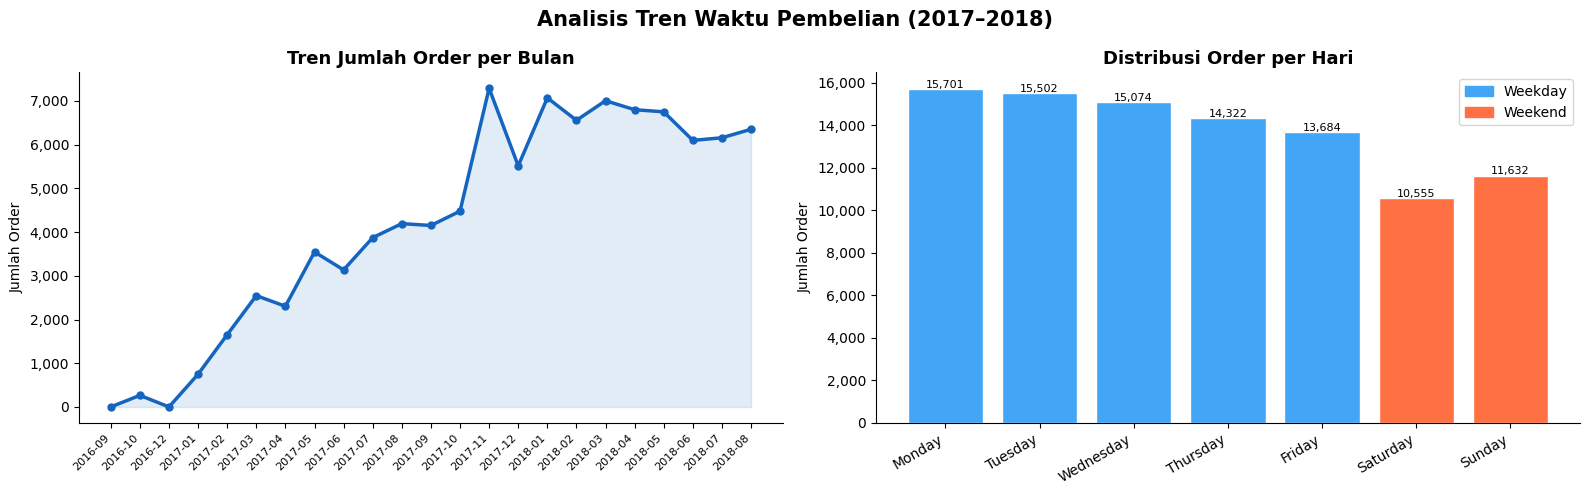

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Line chart tren bulanan
ax = axes[0]
x = range(len(monthly_orders))
y = monthly_orders['jumlah_order']
ax.plot(x, y, marker='o', color='#1565C0', linewidth=2.5, markersize=5)
ax.fill_between(x, y, alpha=0.12, color='#1565C0')
ax.set_xticks(x)
ax.set_xticklabels(monthly_orders['year_month_str'], rotation=45, ha='right', fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{int(v):,}'))
ax.set_title('Tren Jumlah Order per Bulan', fontweight='bold', fontsize=13)
ax.set_ylabel('Jumlah Order')
ax.spines[['top','right']].set_visible(False)

# Bar chart per hari
ax2 = axes[1]
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
daily_vals = orders_clean.groupby('day_of_week').size().reindex(day_order).values
c = ['#42A5F5' if i < 5 else '#FF7043' for i in range(7)]
bars = ax2.bar(day_order, daily_vals, color=c, edgecolor='white')
for bar in bars:
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50, f'{int(bar.get_height()):,}', ha='center', fontsize=8)
ax2.set_title('Distribusi Order per Hari', fontweight='bold', fontsize=13)
ax2.set_ylabel('Jumlah Order')
ax2.set_xticklabels(day_order, rotation=30, ha='right')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{int(v):,}'))
ax2.spines[['top','right']].set_visible(False)
from matplotlib.patches import Patch
ax2.legend(handles=[Patch(color='#42A5F5',label='Weekday'),Patch(color='#FF7043',label='Weekend')])

plt.suptitle('Analisis Tren Waktu Pembelian (2017–2018)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_order_trend.png', dpi=150, bbox_inches='tight')
plt.show()

### Pertanyaan 2:

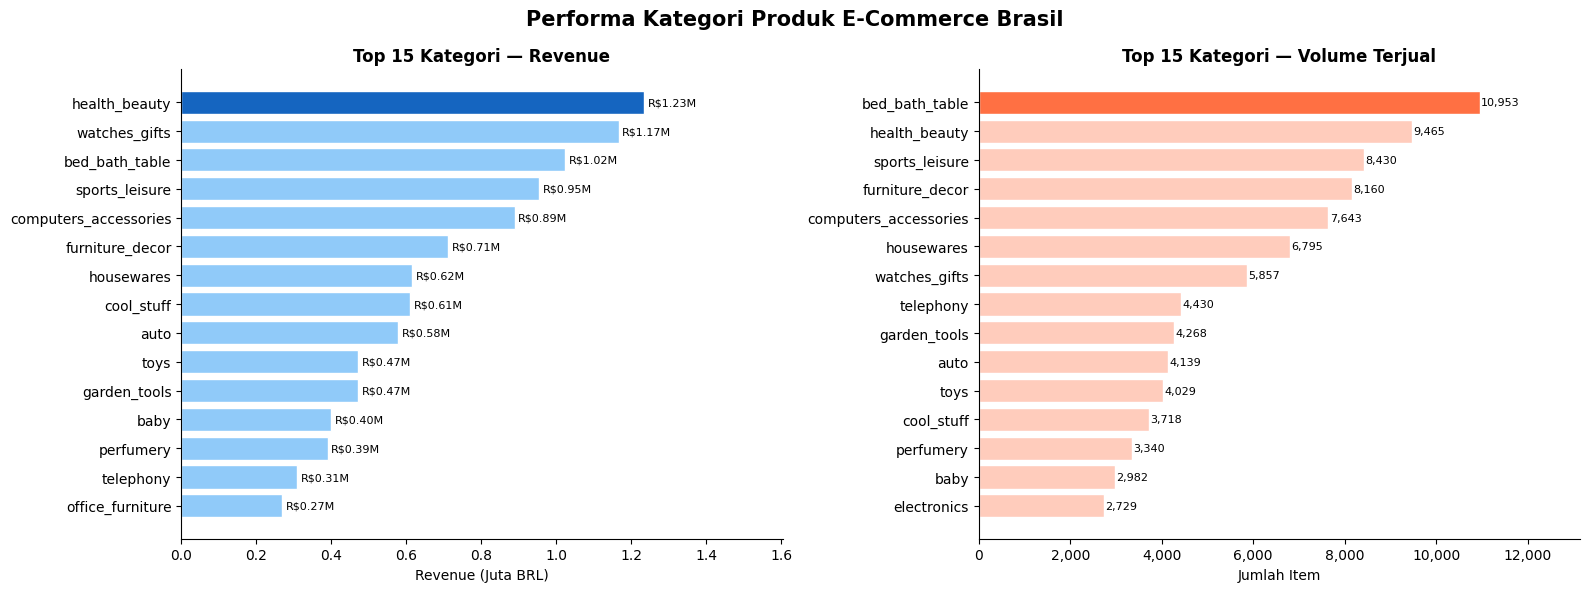

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top15_rev = cat_stats.head(15)
top15_vol = cat_stats.sort_values('total_items',ascending=False).head(15)

ax = axes[0]
c_rev = ['#1565C0' if i==0 else '#90CAF9' for i in range(15)]
bars = ax.barh(top15_rev['product_category_name_english'][::-1], top15_rev['total_revenue'][::-1]/1e6, color=c_rev[::-1], edgecolor='white')
for bar, val in zip(bars, top15_rev['total_revenue'][::-1]/1e6):
    ax.text(bar.get_width()+0.01, bar.get_y()+bar.get_height()/2, f'R${val:.2f}M', va='center', fontsize=8)
ax.set_title('Top 15 Kategori — Revenue', fontweight='bold', fontsize=12)
ax.set_xlabel('Revenue (Juta BRL)')
ax.set_xlim(0, top15_rev['total_revenue'].max()/1e6*1.3)
ax.spines[['top','right']].set_visible(False)

ax2 = axes[1]
c_vol = ['#FF7043' if i==0 else '#FFCCBC' for i in range(15)]
bars2 = ax2.barh(top15_vol['product_category_name_english'][::-1], top15_vol['total_items'][::-1], color=c_vol[::-1], edgecolor='white')
for bar, val in zip(bars2, top15_vol['total_items'][::-1]):
    ax2.text(bar.get_width()+30, bar.get_y()+bar.get_height()/2, f'{val:,}', va='center', fontsize=8)
ax2.set_title('Top 15 Kategori — Volume Terjual', fontweight='bold', fontsize=12)
ax2.set_xlabel('Jumlah Item')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{int(v):,}'))
ax2.set_xlim(0, top15_vol['total_items'].max()*1.2)
ax2.spines[['top','right']].set_visible(False)

plt.suptitle('Performa Kategori Produk E-Commerce Brasil', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_category.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:**
### Visualisasi 1: Analisis Tren Waktu Pembelian

**Tren Jumlah Order per Bulan:**  
Grafik line chart menunjukkan pertumbuhan order yang konsisten dari September 2016
hingga Agustus 2018. Terdapat lonjakan signifikan pada **November 2017** yang
mencapai puncak tertinggi (~7.288 order), yang sangat erat kaitannya dengan
event **Black Friday**. Setelah November 2017, volume order tetap stabil di kisaran
6.000–7.000 order per bulan hingga pertengahan 2018.

**Distribusi Order per Hari dalam Seminggu:**  
Bar chart menunjukkan pola yang jelas bahwa **Senin (15.701)** dan **Selasa (15.502)**
adalah hari dengan order terbanyak. Volume order menurun secara bertahap menuju
akhir pekan, dengan **Sabtu (10.555)** menjadi hari paling sepi. Menariknya,
**Minggu (11.632)** sedikit lebih tinggi dari Sabtu, kemungkinan karena pelanggan
mulai menyiapkan pembelian menjelang awal pekan.
### Visualisasi 2: Performa Kategori Produk

**Top 15 Kategori — Revenue:**  
Kategori **health_beauty** memimpin dengan revenue tertinggi sebesar $1.23 juta diikuti watchesgive ($1.17 juta) dan bed_bath_table ($1.02 juta).
Ketiga kategori ini menyumbang lebih dari 30% dari total revenue keseluruhan.
Kategori **computers_accessories** menarik perhatian karena meskipun berada
di peringkat ke-5 revenue, harga rata-ratanya cukup tinggi dibanding volume yang terjual.

**Top 15 Kategori — Volume Terjual:**  
Dari sisi volume, **bed_bath_table** justru menjadi yang teratas dengan **10.953 item**,
mengungguli health_beauty yang hanya **9.465 item**. Ini menunjukkan bahwa produk
rumah tangga memiliki frekuensi pembelian yang sangat tinggi dengan harga lebih terjangkau.
Kategori **sports_leisure** dan **furniture_decor** juga masuk top 5 volume
meskipun tidak masuk top 5 revenue, mengindikasikan margin yang lebih tipis
pada kategori tersebut.

## Analisis Lanjutan (Opsional)

## Conclusion

**Pertanyaan 1 — Tren Order:**
**Hasil Analisis:**
- Tren jumlah order menunjukkan pertumbuhan yang konsisten dari September 2016
  hingga Agustus 2018, dengan rata-rata peningkatan order setiap bulannya.
- Puncak order tertinggi terjadi pada **November 2017** dengan ~7.288 order,
  yang sangat erat kaitannya dengan event **Black Friday**.
- Dari sisi hari, **Senin (15.701 order)** dan **Selasa (15.502 order)**
  adalah hari paling ramai, sementara **Sabtu (10.555 order)** menjadi
  hari paling sepi dalam seminggu.

**Rekomendasi:**
- 🗓️ **Jadwalkan kampanye promosi besar di bulan November**, khususnya
  memanfaatkan momen Black Friday untuk mendorong lonjakan penjualan
  seperti yang terjadi pada 2017.
- 📅 **Kirimkan notifikasi, email blast, dan iklan di hari Senin dan Selasa**
  karena terbukti menjadi hari dengan aktivitas belanja tertinggi.
- 📉 **Buat promo khusus akhir pekan (Sabtu–Minggu)** untuk mendongkrak
  transaksi di hari-hari yang selama ini sepi, misalnya flash sale atau
  gratis ongkir khusus weekend.

**Pertanyaan 2 — Kategori Produk:**
-**Top 15 Kategori — Revenue:**  
Kategori **health_beauty** memimpin dengan revenue tertinggi sebesar R$1.23 juta, diikuti watches gifts (R$1.17 juta) dan **bed_bath_table (R$1.02 juta)**.
Ketiga kategori ini menyumbang lebih dari 30% dari total revenue keseluruhan.
Kategori **computers_accessories** menarik perhatian karena meskipun berada
di peringkat ke-5 revenue, harga rata-ratanya cukup tinggi dibanding volume yang terjual.

**Top 15 Kategori — Volume Terjual:**  
Dari sisi volume, **bed_bath_table** justru menjadi yang teratas dengan **10.953 item**,
mengungguli health_beauty yang hanya **9.465 item**. Ini menunjukkan bahwa produk
rumah tangga memiliki frekuensi pembelian yang sangat tinggi dengan harga lebih terjangkau.
Kategori **sports_leisure** dan **furniture_decor** juga masuk top 5 volume
meskipun tidak masuk top 5 revenue, mengindikasikan margin yang lebih tipis
pada kategori tersebut.